In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import requests
import string
from collections import Counter

In [2]:
RED = "\033[31;1m"
GREEN = "\033[32;1m"
YELLOW = "\033[33;1m"
BLUE = "\033[34;1m"
PURPLE = "\033[35;1m"
CYAN = "\033[36;1m"
WHITE = "\033[37;1m"

'''
class LSTM_Explanation:
  def __init__(self) -> None:
    self.vocab_size = 100
    self.embed_size = 64
    self.hidden_size = 128
    self.seq_length = 10
    self.batch_size = 32

  def explain_lstm_gates(self):
    print(f"{RED}—LSTM Gates Explanation—")
    print()

    print(f"{BLUE}1. Forget Gate:")
    print(f"{PURPLE} Purpose: Decides what information to throw away from cell state")
    print(f"Formula: f_t = σ(W_f . [h_{{t-1}}, x_t] + b_f)")
    print("   Output: Values between 0 and 1 (0 = completely forget, 1 = completely remember)")
    print()

    print("2. INPUT GATE:")
    print("   Purpose: Decides what new information to store in cell state")
    print("   Formula: i_t = σ(W_i · [h_{t-1}, x_t] + b_i)")
    print("   Candidate: C̃_t = tanh(W_C · [h_{t-1}, x_t] + b_C)")
    print("   Output: i_t determines how much of C̃_t to add to cell state")
    print()

    print("3. OUTPUT GATE:")
    print("   Purpose: Decides what parts of cell state to output as hidden state")
    print("   Formula: o_t = σ(W_o · [h_{t-1}, x_t] + b_o)")
    print("   Hidden: h_t = o_t * tanh(C_t)")
    print()

    print("Where:")
    print("   σ = sigmoid function (outputs 0-1)")
    print("   tanh = hyperbolic tangent (outputs -1 to 1)")
    print("   W = weight matrices")
    print("   b = bias vectors")
    print("   [h_{t-1}, x_t] = concatenation of previous hidden state and current input")

  def explain_data_flow(self):
        """
        Explain how data flows through the Shakespeare RNN
        """
        print("\n=== DATA FLOW IN SHAKESPEARE RNN ===")
        print()

        print("Step 1: INPUT PREPARATION")
        print(f"   Raw text: 'To be or not to be'")
        print(f"   Character mapping: T->1, o->2, space->3, b->4, e->5, etc.")
        print(f"   Input sequence: [1, 2, 3, 4, 5, 3, 2, 7, 3, 8, 2, 1]")
        print(f"   Shape: (batch_size={self.batch_size}, seq_length={self.seq_length})")
        print()

        print("Step 2: EMBEDDING LAYER")
        print(f"   Converts character indices to dense vectors")
        print(f"   Input shape: ({self.batch_size}, {self.seq_length})")
        print(f"   Output shape: ({self.batch_size}, {self.seq_length}, {self.embed_size})")
        print(f"   Each character becomes a {self.embed_size}-dimensional vector")
        print()

        print("Step 3: LSTM PROCESSING")
        print(f"   Input: ({self.batch_size}, {self.seq_length}, {self.embed_size})")
        print(f"   Hidden state: ({self.batch_size}, {self.hidden_size})")
        print(f"   Cell state: ({self.batch_size}, {self.hidden_size})")
        print(f"   Output: ({self.batch_size}, {self.seq_length}, {self.hidden_size})")
        print()

        print("Step 4: OUTPUT LAYER")
        print(f"   Linear layer maps hidden states to vocabulary probabilities")
        print(f"   Input: ({self.batch_size}, {self.seq_length}, {self.hidden_size})")
        print(f"   Output: ({self.batch_size}, {self.seq_length}, {self.vocab_size})")
        print(f"   Each position predicts probability distribution over all characters")

  def explain_training_process(self):
        """
        Explain how training works
        """
        print("\n=== TRAINING PROCESS ===")
        print()

        print("1. SEQUENCE PREPARATION:")
        print("   Input:  'To be or not to b'  (sequence_length characters)")
        print("   Target: 'o be or not to be'  (same sequence shifted by 1)")
        print("   Goal: Predict next character at each position")
        print()

        print("2. FORWARD PASS:")
        print("   - Embedding converts characters to vectors")
        print("   - LSTM processes sequence step by step")
        print("   - At each step, LSTM updates its internal memory")
        print("   - Output layer produces probability distribution")
        print()

        print("3. LOSS CALCULATION:")
        print("   - CrossEntropyLoss compares predicted vs actual next characters")
        print("   - Loss is averaged across all positions and batch samples")
        print()

        print("4. BACKPROPAGATION:")
        print("   - Gradients flow backward through time (BPTT)")
        print("   - LSTM gates help gradients flow better than vanilla RNN")
        print("   - Gradient clipping prevents exploding gradients")
        print()

        print("5. PARAMETER UPDATE:")
        print("   - Adam optimizer updates weights based on gradients")
        print("   - Model learns to predict character patterns")
'''

'''
class LSTM_Cell:
  def __init__(self, input_size, hidden_size) -> None:
    self.input_size = input_size
    self.hidden_size = hidden_size

    #Initializing weights
    self.W_f = np.random.randn(hidden_size, input_size + hidden_size) * 0.1
    self.b_f = np.zeros(hidden_size)

    self.W_i = np.random.randn(hidden_size, input_size + hidden_size) * 0.1
    self.b_i = np.zeros(hidden_size)

    self.W_C = np.random.randn(hidden_size, input_size + hidden_size) * 0.1
    self.b_C = np.zeros(hidden_size)

    self.W_o = np.random.rand(hidden_size, input_size + hidden_size) * 0.1
    self.b_o = np.zeros(hidden_size)
'''

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
def download_data():
  url = "https://www.gutenberg.org/files/11/11-0.txt"
  response = requests.get(url)
  text = response.text

  #Finding the start and end of book content
  start = text.find("CHAPTER I.")
  end = text.find("THE END")

  if start == 0:
    start = 0
  if end == -1:
    end = len(text)

  text = text[start:end+1]
  return text


In [5]:
def preprocess_text(text):
  #Converting to lowercase and keeping only letters, spaces, and basic punctuation
  allowed_chars = string.ascii_lowercase + string.digits + ".,!?'-\n"
  text = "".join([char.lower() if char.lower() in allowed_chars else " " for char in text])

  #Removing whitespaces
  text = " ".join(text.split())
  return text

In [6]:
#Creating character mapping
def create_mapping(text):
  chars = sorted(list(set(text)))
  char_to_idx = {char:i for i, char in enumerate(chars)}
  idx_to_char = {i:char for i, char in enumerate(chars)}
  return chars, char_to_idx, idx_to_char

In [7]:
#Creating training sequences
def create_sequences(text, char_to_idx, seq_length=100):
  sequences = []
  targets = []

  for i in range(len(text)-seq_length):
    seq = text[i: i+seq_length]
    target = text[i+1: i+seq_length+1]

    sequences.append([char_to_idx[char] for char in seq])
    targets.append([char_to_idx[char] for char in target])

  return np.array(sequences), np.array(targets)

In [8]:
class SimpleRNN(nn.Module):
  def __init__(self, vocab_size:int, hidden_size:int, num_layers=2):
    super(SimpleRNN, self).__init__()
    self.hidden_size = hidden_size
    self.num_layers = num_layers
    self.vocab_size = vocab_size

    #Embedding Layers
    self.embeddings = nn.Embedding(vocab_size, hidden_size)

    #RNN Layer
    self.rnn = nn.RNN(hidden_size, hidden_size, num_layers, batch_first=True)

    #Output Layer
    self.fc = nn.Linear(hidden_size, vocab_size)

  def forward(self, x, hidden=None):
    # x: shape(batch_size, seq_Length)
    batch_size = x.size(0)

    # Initializing the hidden layer if not provided
    if hidden is None:
      hidden = self.init_hidden(batch_size)

    # Embeddings
    embedded = self.embeddings(x) # (batch_size, seq_length, hidden_size)

    #RNN
    output, hidden = self.rnn(embedded, hidden) # Output: (batch_size, seq_length, hidden_size)

    #Reshape for Linear Layer
    output = output.reshape(-1, self.hidden_size) # Output: (batch_size * seq_length, hidden_size)
    outline = self.fc(output)

    return output, hidden

  def init_hidden(self, batch_size):
      return torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)

In [9]:
#Training Function
def train_model(model, sequences, targets, epochs=50, batch_size=32, learning_rate=0.002):
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr=learning_rate)

  #Converting to tensors
  sequences = torch.LongTensor(sequences).to(device)
  targets = torch.LongTensor(targets).to(device)

  losses = []

  for epoch in range(0, epochs):
    total_loss = 0
    hidden = model.init_hidden(batch_size)

    #Shuffling data
    indices = torch.randperm(len(sequences))

    for i in range(0, len(indices), batch_size):
      batch_indices = indices[i:i+batch_size]
      if len(batch_indices) != batch_size:
        continue

      batch_sequences = sequences[batch_indices]
      batch_targets = targets[batch_indices]

      #Resetting Gradients
      optimizer.zero_grad()

      #Forward Propogation
      output, hidden = model(batch_sequences, hidden.detach())

      #Reshaping outputs to match output
      batch_targets = batch_targets.reshape(-1)

      #Calculating loss
      loss = criterion(output, batch_targets)

      #Backpropagation
      loss.backward()

      #Clip gradients to prevent exploding gradient
      torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)

      #Updating weights
      optimizer.step()

      total_loss += loss.item()

    avg_loss = total_loss / (len(indices) // batch_size)
    losses.append(avg_loss)

    if epoch % 10 == 0:
      print(f"{BLUE}Epoch: [{epoch}/{epochs}], Loss: {avg_loss:.4f}")

  return losses


In [10]:
#Text generation function
def generate_text(model, char_to_idx, idx_to_char, seed_text, Length=200, temperature=0.5):
  model.eval()

  #Converting seed text to indices
  seed_indices = [char_to_idx.get(char, 0) for char in seed_text.lower()]
  generated = seed_indices.copy()

  #Initializing hidden state
  hidden = model.init_hidden(1)

  with torch.no_grad():
    #Process seed text
    for i in range(len(seed_indices)-1):
      input_tensor = torch.LongTensor([[seed_indices[i]]]).to(device)
      output, hidden = model(input_tensor, hidden)

    #Generate new characters
    input_char = seed_indices[-1]

    for _ in range(0, Length):
      input_tensor = torch.LongTensor([[input_char]]).to(device)
      output, hidden = model(input_tensor, hidden)

      #Applying temperature across scaling
      output = output.squeeze()/temperature
      probabilities = torch.softmax(output, dim=0)

      #Samples from distribution
      char_idx = torch.multinomial(probabilities, 1).item()
      generated.append(char_idx)
      input_char = char_idx

  generated_text = "".join([idx_to_char[idx] for idx in generated])
  return generated_text

In [11]:
def main():
  print(f"{PURPLE}Downloading and preparing data")
  text = download_data()
  text = preprocess_text(text)
  print(f"{BLUE}Text Length: {len(text)} characters")

  #Creating character mappings
  chars, char_to_idx, idx_to_char = create_mapping(text)
  vocab_size = len(chars)
  print(f"{WHITE}Vocabulary Size: {vocab_size}")
  print(f"Characters: {''.join(chars[:20])}")

  #Creating training sequences
  seq_length = 100
  sequences, targets = create_sequences(text, char_to_idx, seq_length)
  print(f"{YELLOW}Number of training sequences: {len(sequences)}")

  #Initializing model
  hidden_size = 128
  num_layers=2
  model = SimpleRNN(vocab_size, hidden_size, num_layers).to(device)
  print(f"{GREEN}Model Parameters: {sum(p.numel() for p in model.parameters()):,}")

  #Training model
  print(f"{GREEN}Training Starts")
  losses = train_model(model, sequences, targets, epochs=30, batch_size=64)

  #Plotting training loss
  plt.figure(figsize=(10, 8))
  plt.plot(losses)
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.title("Training Loss")
  plt.grid("True")
  plt.show()

  #Generating sample text
  print("\nGenerating sample text")
  seed_texts = ["alice", "the rabbit", "once upon"]

  for seed in seed_texts:
    print("\nSeed: `{seed}`")
    generated_text = generate_text(model, char_to_idx, idx_to_char, seed, Length=150)
    print(f"{GREEN}generated")
    print("=" * 80)

Text Length: 139536 characters
Vocabulary Size: 32
Characters:  !,-.?abcdefghijklmn
Number of training sequences: 139436
Model Parameters: 74,272
Training Starts
Epoch: [0/30], Loss: 3.2233
Epoch: [10/30], Loss: 3.1327
Epoch: [20/30], Loss: 3.1302


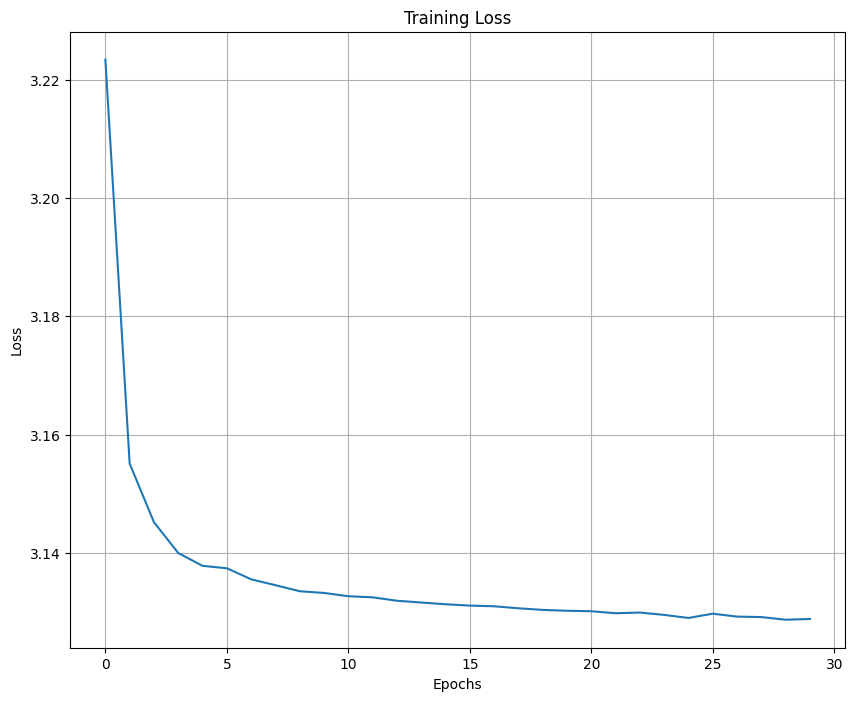


Generating sample text

Seed: `{seed}`


AcceleratorError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [12]:
main()